# Basic setup

We will investigate stochastic processes that satisfy the stochastic differential equation
$$
(*) \begin{cases}
& d X_t = \mu(t, X_t) dt + \sigma(t, X_t) dW_t, \\
& X_0 = x_0
\end{cases}
$$
where $W_t$ is a Wiener process (or Browninan motion).

In this set up, we get that 
$$
X_t = x_0 + \int_0^t \mu(s, X_s) \, ds + \int_0^t \sigma(s, X_s) \, dW_s.
$$

## Geometric Brownian Motion
This is a generalization of first order linear ODEs. It is given in the form
$$
(GBM) \begin{cases}
    & dX_t = \alpha X_t dt + \sigma X_t dW_t, \\
    & X_0 = x_0.
\end{cases}
$$

We formally divide by $dt$ to rearrange our equation into
$$
\frac{dX_t}{dt} = \alpha X_t + \sigma X_t \frac{dW_t}{dt} = (\alpha + \sigma \dot{W_t})X_t.
$$
Here $\dot{W_t}$ can be interpreted as white-noise, which is the formal derivative of the Wiener Process. The solutions will have expected value
$$
E(X_t) = x_0 e^{\alpha t}.
$$


Now let's try to simulate the below.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [61]:
# Simulation parameters
dt = 0.01
x0 = 1.0
alpha = 1.0
sigma = 0.2

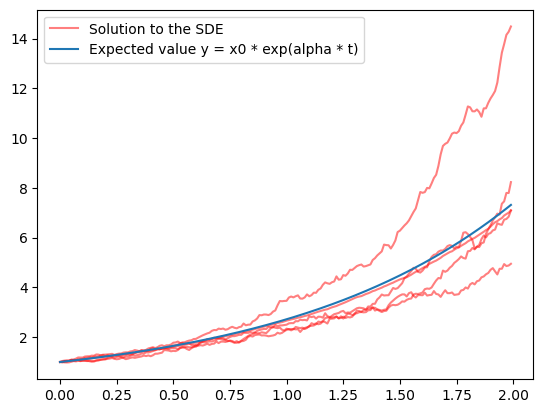

In [76]:
xs = np.arange(0, 2, dt)

expected = x0 * np.exp(alpha * xs)

for i in range(4):

    noise = np.random.normal(0, np.sqrt(dt), xs.shape[0])

    X_t = np.ones(xs.shape[0]) * x0

    for i in range(1, xs.shape[0]):
        X_t[i] = X_t[i-1] + alpha * X_t[i-1] * dt + sigma * X_t[i-1] * noise[i]
    plt.plot(xs, X_t, color='red', alpha=0.5)
noise = np.random.normal(0, dt, xs.shape[0])

X_t = np.ones(xs.shape[0]) * x0

for i in range(1, xs.shape[0]):
    X_t[i] = X_t[i-1] + alpha * X_t[i-1] * dt + sigma * X_t[i-1] * noise[i]
plt.plot(xs, X_t, color='red', alpha=0.5, label='Solution to the SDE')

plt.plot(xs, expected, label='Expected value y = x0 * exp(alpha * t)')
plt.legend()
plt.show()

To solve this SDE, we will do the following: 
- Set $Y_t = \log (X_t)$,
- Then we can use Ito's Lemma to find that
$$
d Y = \frac{1}{X} dX + \frac{1}{2} \left( -\frac{1}{X^2} (dX)^2 \right).
$$
- Plug in $dX_t = \alpha X_t dt + \sigma X_t dW_t$, we get $(dX)^2 = \sigma^2 X^2 dt$, and so
- $dY = \frac{1}{X} (\alpha X dt + \sigma X dW) - \frac{1}{2}\sigma^2 dt$.
- Cleaning this up, $dY = (\alpha - \sigma^2/2) dt + \sigma dW.$
- $Y = \log(x_0) + \int_0^t \alpha - \sigma^2/2 \, ds + \int_0^t \sigma dW_s$,
- Which gives us
$$
X_t = x_0 \exp \left(\int_0^t \alpha - \frac{1}{2} \sigma^2 ds + \int_0^t \sigma dW_s \right) = x_0 \exp \left( \left( \alpha - \frac{\sigma^2}{2} \right) t + \sigma W_t \right)
$$

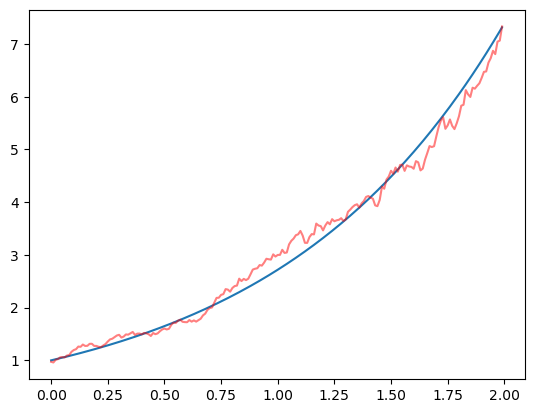

In [113]:
# We can try to model this solution and see if it agrees with what's going on the in above simulations.

wiener = np.random.normal(0, np.sqrt(dt), xs.shape[0])
wiener = np.cumsum(wiener)

soln = x0 * np.exp((alpha - 0.5 * sigma * sigma) * xs + sigma * wiener)
plt.plot(xs, expected)
plt.plot(xs, soln, color='red', alpha=0.5)

plt.show()

Running the above simulation many times gives us something similar to what we have above.